**Alunos**:
- Rodrigo Macedo
- Icaro Yan
- Iago Alfaya

In [ ]:
# Formatar resultado para: x.xx%
def format_percetual(value):
  return f'{100* value:.2f}%'

In [ ]:
# Função para detectar outliers usando o método IQR
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers

In [ ]:
def remove_outilier(value,dataSet):

    # Filtrando os Outliers
    Q1 = dataSet[value].quantile(0.25)
    Q3 = dataSet[value].quantile(0.75)
    IQR = Q3 - Q1

    #Alocando os dados sem os outlier's na variavel
    return dataSet[(dataSet[value] >= Q1 - 1.5*IQR) & (dataSet[value] <= Q3 + 1.5*IQR)]


# Dados extras

## Importando dados de 'Nyk Open Dataset' (Falhou)

---



In [ ]:
!mkdir data

mkdir: cannot create directory ‘data’: File exists


In [ ]:
!unzip data/Annualized_Rolling_Sales_Update.zip -d data/

unzip:  cannot find or open data/Annualized_Rolling_Sales_Update.zip, data/Annualized_Rolling_Sales_Update.zip.zip or data/Annualized_Rolling_Sales_Update.zip.ZIP.


### verificando como os dados estão nos datasets

In [ ]:
dp_brooklyn_2014 = pd.read_excel('data/2009_brooklyn.xls')
dp_brooklyn_2014

FileNotFoundError: [Errno 2] No such file or directory: 'data/2009_brooklyn.xls'

In [ ]:
import pandas as pd
import glob
import os
import re

# Caminho para a pasta com os arquivos
path = "data/"

# Criar a pasta 'data' se não existir para evitar erros no glob
os.makedirs(path, exist_ok=True)
files = glob.glob(os.path.join(path, "*.xls"))
dfs = []

for file in files:
    year = None
    borough = None

    # Extrair ano e bairro do nome do arquivo
    match = re.search(r'(\\d{4})[_-]?(bronx|brooklyn|manhattan|queens|statenisland|si)', file, re.IGNORECASE)
    if match:
        year = match.group(1)
        # Padronizar 'si' para 'statenisland'
        borough = match.group(2).lower()
        if borough == 'si':
            borough = 'statenisland'

    try:
        df = pd.read_excel(file)
    except Exception as e:
        print(f"Erro ao ler o arquivo {file} com cabeçalho padrão: {e}. Tentando sem cabeçalho.")
        df = pd.read_excel(file, header=None)

    # Remover as duas primeiras linhas após a leitura, se o DataFrame não estiver vazio
    if not df.empty and len(df) > 3:
        df = df.iloc[2:].copy()
    elif not df.empty and len(df) <= 2:
        print(f"Aviso: O arquivo {file} tem {len(df)} linhas, menos ou igual a 2. Nenhuma linha será removida.")
        continue
    elif df.empty:
        print(f"Aviso: O arquivo {file} está vazio. Pulando.")
        continue

    # Adicionar colunas de contexto
    df["year"] = year
    df["borough"] = borough

    # Padronizar nomes das colunas
    if not df.empty:
        df.columns = [str(c).strip().lower().replace(" ", "_") for c in df.columns]

    dfs.append(df)

# Concatenar tudo
if dfs:
    final_df = pd.concat(dfs, ignore_index=True)
    # Reorganizar colunas, se final_df não estiver vazio
    if not final_df.empty:
        cols = ["year", "borough"] + [c for c in final_df.columns if c not in ["year", "borough"]]
        final_df = final_df[cols]

        # Salvar resultado
        final_df.to_csv("sales_nyc_2003_2015.csv", index=False)
        print("Processamento concluído e 'sales_nyc_2003_2015.csv' criado com sucesso.")
    else:
        print("Nenhum dado processado. 'sales_nyc_2003_2015.csv' não foi criado.")
else:
    print("Nenhum arquivo Excel encontrado ou processado. 'sales_nyc_2003_2015.csv' não foi criado.")

In [ ]:
import pandas as pd

nyk = pd.read_csv('sales_nyc_2003_2015.csv')
nyk.dtypes

In [ ]:
print(nyk['queens_all_sales_for_2004_(january_2004_-_december_2004)'])

In [ ]:

for bairro, data, preco in zip()

## Importando dados de 'Nyk Open Dataset' (falhou 2.0)

In [ ]:
import pandas as pd
import zipfile

# Caminho do arquivo ZIP
zip_path = "/content/data/Annualized_Rolling_Sales_Update.zip"

# Nome da coluna que você quer extrair
coluna_desejada = "YEAR BUILT"

# Lista para armazenar os dados de todos os arquivos
tudo = []

with zipfile.ZipFile(zip_path, 'r') as z:
    for file in z.namelist():
        if file.endswith(".xls") or file.endswith(".xlsx"):
            with z.open(file) as f:
                df = pd.read_excel(f)
                if coluna_desejada in df.columns:
                    # Pega apenas a coluna desejada
                    tudo.append(df[[coluna_desejada]])
                else:
                    print(f"A coluna '{coluna_desejada}' não existe em {file}")

# Juntar tudo em um único DataFrame
final_df = pd.concat(tudo, ignore_index=True)

# Mostrar resultado
print(final_df.head())


# AED

## Dataset NYK do professor

**Descrição dos tipos das colunas:**
*   **BROKERTITLE**: Nominal
*   **TYPE**: Nominal
*   **PRICE**: Razão
*   **BEDS**: Razão
*   **BATH**: Razão
*   ***PROPERTYSQFT***: Razão
*   **ADDRESS, STATE, MAIN_ADDRESS, ADMINISTRATIVE_AREA_LEVEL_2, LOCALITY, SUBLOCALITY, STREET_NAME, LONG_NAME, FORMATTED_ADDRESS**: Nominal
*   **LATITUDE, LONGITUDE**: Razão



### Analise Inicial

In [ ]:
import pandas as pd

professor = pd.read_csv('NY-House-Dataset.csv')
professor

In [ ]:
professor = professor.drop(columns=['MAIN_ADDRESS', 'STATE', 'ADDRESS', 'ADMINISTRATIVE_AREA_LEVEL_2', 'LOCALITY', 'LONG_NAME', 'STREET_NAME'])

Durante nossa analise, inferimos a necessidade de remoção das colunas

In [ ]:
professor.info()

In [ ]:
professor.isna().sum()

In [ ]:
(professor.isna().sum() / len(professor)).apply(format_percetual)

In [ ]:
professor.describe()

In [ ]:
count_street = professor[['SUBLOCALITY', 'TYPE']].value_counts()

In [ ]:
filtro_outlier_p = remove_outilier('PRICE',professor)
professor = filtro_outlier_p

In [ ]:
import numpy as np
# Calcular matriz de correlação para colunas numéricas
correlation_matrix_p = professor.select_dtypes(include=np.number).corr()
print("Matriz de Correlação:")
print(correlation_matrix_p)

In [ ]:
# Visualizar a matriz de correlação com um heatmap

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix_p, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap da Matriz de Correlação')
plt.show()

In [ ]:
filtro_outlier_p['PROPERTYSQFT'] = filtro_outlier_p['PROPERTYSQFT'] / 3.28084


In [ ]:
ax = sns.lmplot(x="PROPERTYSQFT", y="PRICE", data=filtro_outlier_p)
ax.fig.set_size_inches(12, 6)
ax.fig.suptitle('Reta de Regressão - Banheiros X Quartos', fontsize=16, y=1.02)
ax.set_xlabels("Metragem (metros)", fontsize=14)
ax.set_ylabels("Preço (dolar)", fontsize=14)
ax

In [ ]:
outliers_sale_price = detect_outliers_iqr(professor, 'PRICE')
print(f"Número de outliers em 'PRICE': {len(outliers_sale_price)}")
print("Alguns outliers em 'PRICE':")
print(outliers_sale_price[['PRICE']].head())

In [ ]:
for col in professor.select_dtypes(include=np.number).columns:
    plt.figure(figsize=(8, 5))
    sns.boxplot(y=professor[col])
    plt.title(f'Boxplot de {col}')
    plt.ylabel(col)
    plt.show()

### Analise de dados númericos

In [ ]:
professor.select_dtypes('number')

In [ ]:
professor.describe().round(2)

In [ ]:
from scipy.stats import norm

# Média e desvio padrão
mu = filtro_outlier_p ['PRICE'].mean()
sigma = filtro_outlier_p ['PRICE'].std()

# Histograma
fig, ax = plt.subplots(figsize=(12,5))
sns.histplot(filtro_outlier_p ['PRICE'], bins=30, kde=True, stat='density', color='skyblue', alpha=0.6)

# Curva normal
x = np.linspace(filtro_outlier_p ['PRICE'].min(), filtro_outlier_p['PRICE'].max(), 100)
ax.plot(x, norm.pdf(x, mu, sigma), color='red', lw=2, label='Distribuição Normal')
ax.set_title('Preços de Vendas com Distribuição Normal')
ax.set_xlabel('Preço')
ax.set_ylabel('Densidade')
ax.legend()
plt.show()


### Analise de dados Categóricos

In [ ]:
professor.select_dtypes('object')

In [ ]:
professor.value_counts('BROKERTITLE')

In [ ]:
plt.figure(figsize=(14, 10))
professor['BROKERTITLE'].value_counts().head(50).plot(kind='bar')
plt.title('Top 10 quantidade de título do corretor')
plt.xlabel('Tipos de edificios')
plt.ylabel('Contagem')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
(professor.isna().sum() / len(professor)).apply(format_percetual)

In [ ]:
# Estatísticas descritivas para colunas categóricas
print("Estatísticas descritivas para colunas categóricas:")
print(professor.describe(include='object'))

In [ ]:
ax = sns.lmplot(x="BEDS", y="BATH", data=professor)
ax.fig.set_size_inches(12, 6)
ax.fig.suptitle('Reta de Regressão - Banheiros X Quartos', fontsize=16, y=1.02)
ax.set_xlabels("Número de quartos", fontsize=14)
ax.set_ylabels("Números de banheiros", fontsize=14)
ax

In [ ]:
plt.figure(figsize=(14, 7))
professor['TYPE'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 qantidade de tipos de edificios')
plt.xlabel('Tipos de edificios')
plt.ylabel('Contagem')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(14, 7))
professor['SUBLOCALITY'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 bairros com mais dados de casas')
plt.xlabel('Tipos de edificios')
plt.ylabel('Contagem')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## One Hot Encondig

In [ ]:
categorical_cols = ['BROKERTITLE', 'TYPE', 'SUBLOCALITY', 'FORMATTED_ADDRESS']

In [ ]:
p_encoded = pd.get_dummies(professor, columns=categorical_cols, drop_first=True)

In [ ]:
print(p_encoded.shape)
p_encoded.head()

In [ ]:
for col in categorical_cols:
    novas_colunas = [c for c in p_encoded.columns if c.startswith(col + '_')]
    print(col, "→", len(novas_colunas), "colunas geradas")

## DataSet Asimov Academy

Unnamed: 0: nominal  
BOROUGH: nominal  
NEIGHBORHOOD: nominal  
BUILDING CLASS CATEGORY: nominal  
TAX CLASS AT PRESENT: nominal  
BLOCK: nominal  
LOT: nominal  
EASE-MENT: nominal  
BUILDING CLASS AT PRESENT: nominal  
ADDRESS: nominal  
APARTMENT NUMBER: nominal  
ZIP CODE: nominal  
RESIDENTIAL UNITS: razão  
COMMERCIAL UNITS: razão  
TOTAL UNITS: razão  
LAND SQUARE FEET: razão  
GROSS SQUARE FEET: razão  
YEAR BUILT: intervalar  
TAX CLASS AT TIME OF SALE: nominal  
BUILDING CLASS AT TIME OF SALE: nominal  
SALE PRICE: razão  
SALE DATE: intervalar  
LATITUDE: intervalar  
LONGITUDE: intervalar

### Analise Inicial

In [ ]:
import pandas as pd
import numpy as np

asimov = pd.read_csv('cleaned_data.csv')
asimov.info()

In [ ]:
asimov.isna()

In [ ]:
asimov.isna().sum()

In [ ]:
percent_asimov = (asimov.isna().sum() / len(asimov)).sort_values(ascending=False).reset_index()
percent_asimov

In [ ]:
percent_asimov.columns = ['colunm_name', 'percent_na']

In [ ]:
# Estatísticas descritivas para colunas numéricas
print("Estatísticas descritivas para colunas numéricas:")
print(asimov.describe())


In [ ]:

# Contagem de valores únicos para algumas colunas categóricas
for col in asimov.select_dtypes(include='object').columns:
    print(f"Contagem de valores para a coluna {col}:")
    print(asimov[col].value_counts().head())

### Analisando dados numericos

In [ ]:
asimov.select_dtypes('number')

In [ ]:
asimov.describe().round(2)

In [ ]:
asimov = remove_outilier('SALE PRICE', asimov)

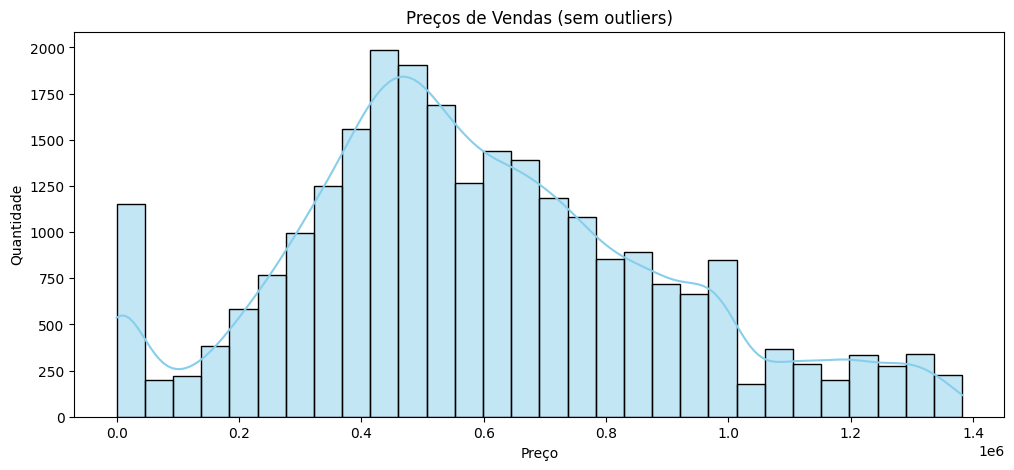

In [ ]:
Q1 = asimov['SALE PRICE'].quantile(0.25)
Q3 = asimov['SALE PRICE'].quantile(0.75)
IQR = Q3 - Q1

#tirando os outlier
filtro_outlier = asimov[(asimov['SALE PRICE'] >= Q1 - 1.5*IQR) & (asimov['SALE PRICE'] <= Q3 + 1.5*IQR)]

fig, ax = plt.subplots(figsize=(12,5))
sns.histplot(filtro_outlier['SALE PRICE'], bins=30, kde=True, color='skyblue')
ax.set_title('Preços de Vendas (sem outliers)')
ax.set_xlabel('Preço')
ax.set_ylabel('Quantidade')

plt.show()


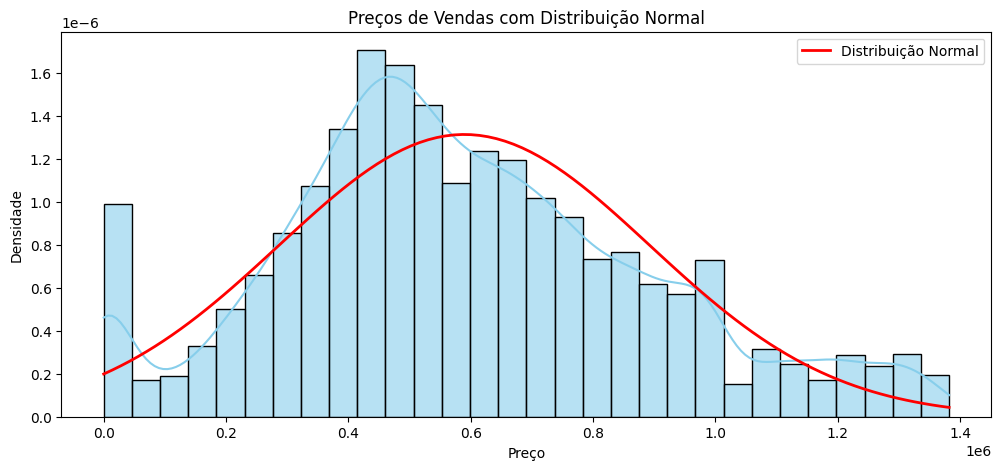

In [ ]:
from scipy.stats import norm

# Média e desvio padrão
mu = filtro_outlier['SALE PRICE'].mean()
sigma = filtro_outlier['SALE PRICE'].std()

# Histograma
fig, ax = plt.subplots(figsize=(12,5))
sns.histplot(filtro_outlier['SALE PRICE'], bins=30, kde=True, stat='density', color='skyblue', alpha=0.6)

# Curva normal
x = np.linspace(filtro_outlier['SALE PRICE'].min(), filtro_outlier['SALE PRICE'].max(), 100)
ax.plot(x, norm.pdf(x, mu, sigma), color='red', lw=2, label='Distribuição Normal')
ax.set_title('Preços de Vendas com Distribuição Normal')
ax.set_xlabel('Preço')
ax.set_ylabel('Densidade')
ax.legend()
plt.show()


In [ ]:
asimov['SALE DATE'] = pd.to_datetime(asimov['SALE DATE'], errors='coerce')

/tmp/ipython-input-1820932319.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  asimov['SALE DATE'] = pd.to_datetime(asimov['SALE DATE'], errors='coerce')


In [ ]:
asimov['YEAR'] = asimov['SALE DATE'].dt.year
(asimov['YEAR'].value_counts(normalize=True, dropna=False).apply(lambda p: f'{100 * p:.2f}%'))


/tmp/ipython-input-384904181.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  asimov['YEAR'] = asimov['SALE DATE'].dt.year


,proportion
YEAR,
2017,64.22%
2016,35.78%


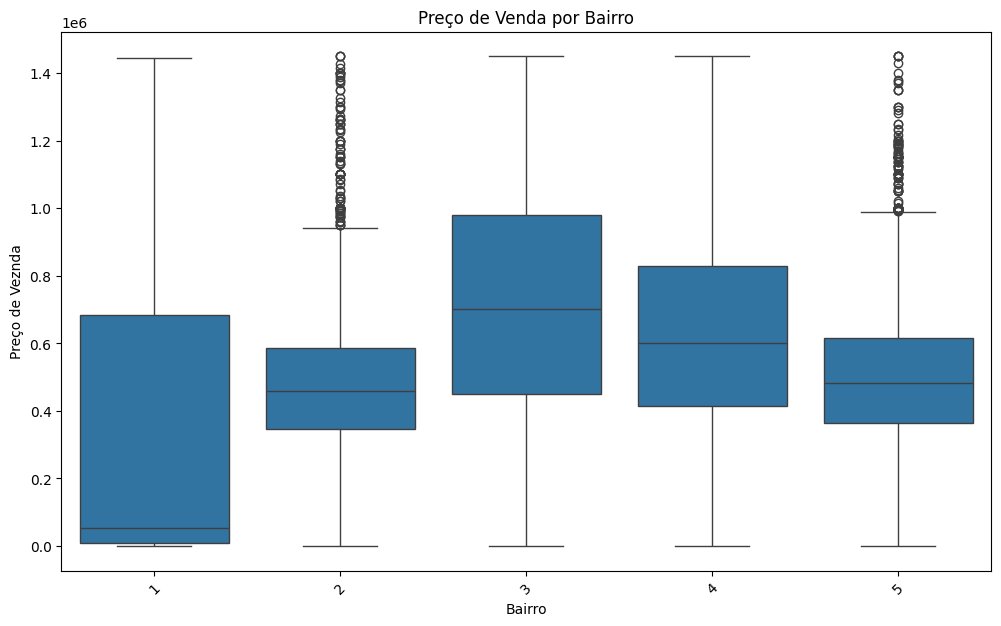

[4 3 5 2 1]


In [ ]:
# Boxplot de SALE PRICE por BOROUGH
plt.figure(figsize=(12, 7))
sns.boxplot(x='BOROUGH', y='SALE PRICE', data=asimov)
plt.title('Preço de Venda por Bairro')
plt.xlabel('Bairro')
plt.ylabel('Preço de Veznda')
plt.xticks(rotation=45)
plt.show()
print(asimov['BOROUGH'].unique())


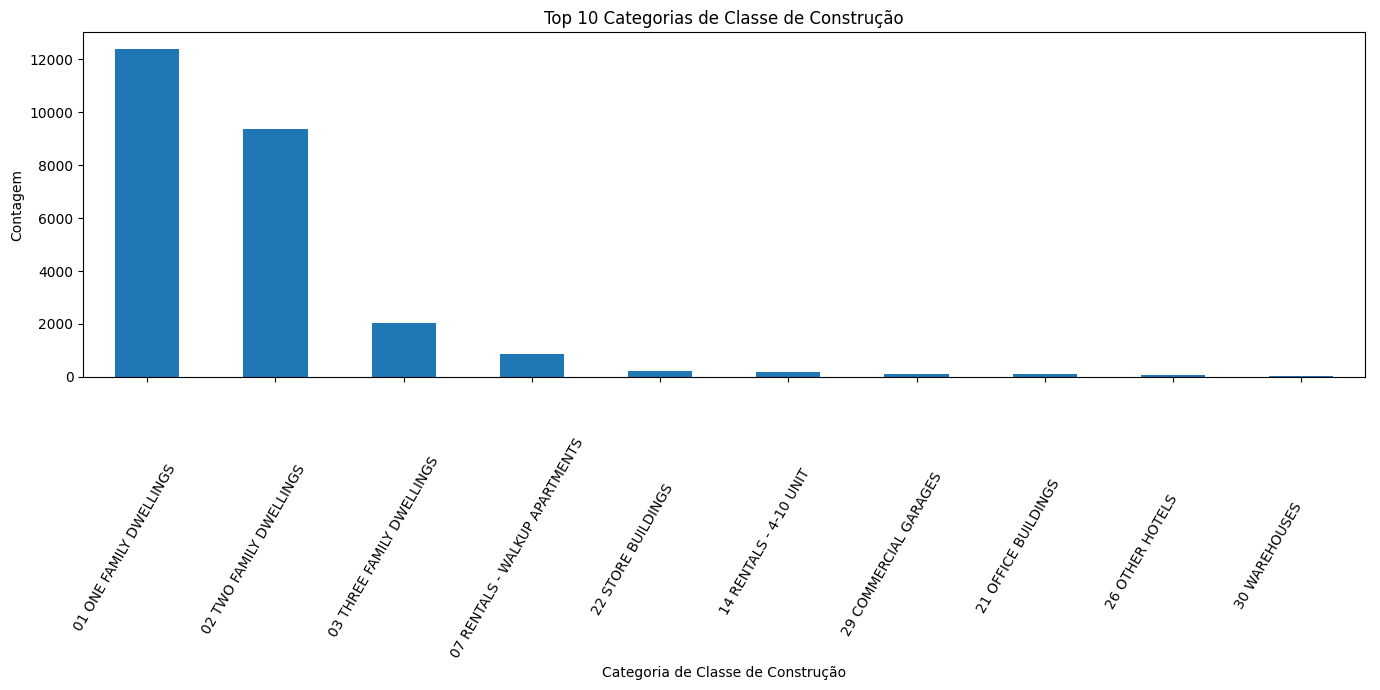

In [ ]:
# Gráfico de barras para a contagem de imóveis por BUILDING CLASS CATEGORY
plt.figure(figsize=(14, 7))
asimov['BUILDING CLASS CATEGORY'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Categorias de Classe de Construção')
plt.xlabel('Categoria de Classe de Construção')
plt.ylabel('Contagem')
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

In [ ]:

# Calcular matriz de correlação para colunas numéricas
correlation_matrix = asimov.select_dtypes(include=np.number).corr()
print("Matriz de Correlação:")
print(correlation_matrix)

Matriz de Correlação:
                           Unnamed: 0   BOROUGH     BLOCK       LOT  ZIP CODE  \
Unnamed: 0                   1.000000  0.040437  0.470938 -0.024077  0.540274   
BOROUGH                      0.040437  1.000000  0.064850  0.023108 -0.067100   
BLOCK                        0.470938  0.064850  1.000000  0.027710  0.483266   
LOT                         -0.024077  0.023108  0.027710  1.000000 -0.088614   
ZIP CODE                     0.540274 -0.067100  0.483266 -0.088614  1.000000   
RESIDENTIAL UNITS           -0.000517 -0.038824 -0.023398 -0.003434 -0.008084   
COMMERCIAL UNITS             0.004220 -0.000872  0.004299 -0.001917  0.003508   
TOTAL UNITS                  0.002665 -0.027636 -0.013227 -0.003753 -0.003126   
LAND SQUARE FEET            -0.003429  0.015470 -0.000368 -0.000708 -0.023371   
GROSS SQUARE FEET           -0.001579 -0.055593 -0.029530 -0.001702 -0.036835   
YEAR BUILT                  -0.139685  0.217821  0.006689  0.075660 -0.217076   
TAX CL

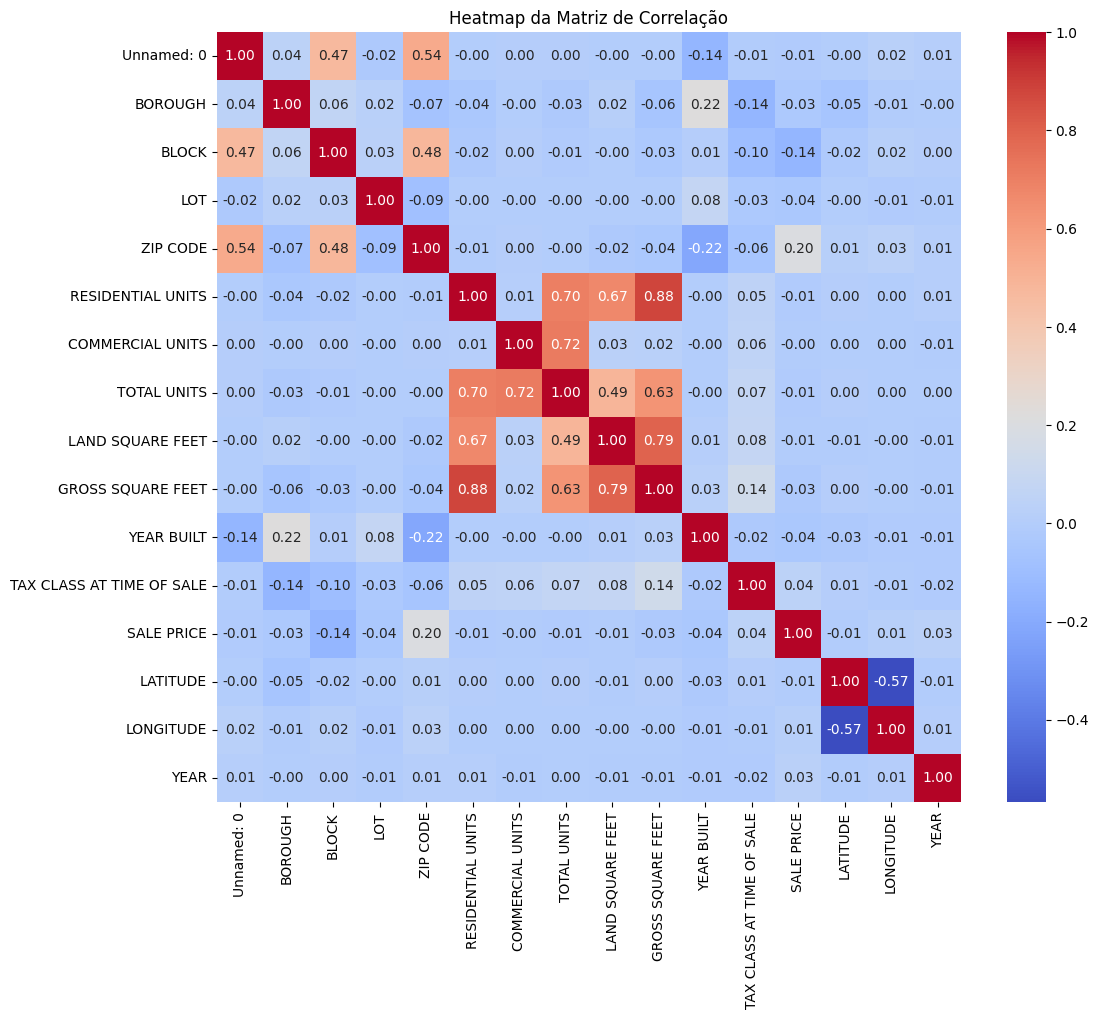

In [ ]:
# Visualizar a matriz de correlação com um heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap da Matriz de Correlação')
plt.show()

In [ ]:
corr = asimov.corr(numeric_only=True)
corr_pairs = corr.unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs < 1]
corr_fortes = corr_pairs[abs(corr_pairs) > 0.35]
print(corr_fortes.head(10))

RESIDENTIAL UNITS  GROSS SQUARE FEET    0.882591
GROSS SQUARE FEET  RESIDENTIAL UNITS    0.882591
LAND SQUARE FEET   GROSS SQUARE FEET    0.792876
GROSS SQUARE FEET  LAND SQUARE FEET     0.792876
COMMERCIAL UNITS   TOTAL UNITS          0.718037
TOTAL UNITS        COMMERCIAL UNITS     0.718037
                   RESIDENTIAL UNITS    0.702201
RESIDENTIAL UNITS  TOTAL UNITS          0.702201
LAND SQUARE FEET   RESIDENTIAL UNITS    0.672210
RESIDENTIAL UNITS  LAND SQUARE FEET     0.672210
dtype: float64


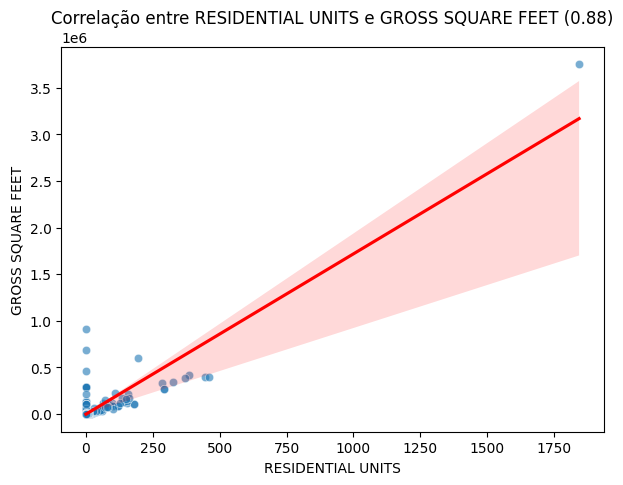

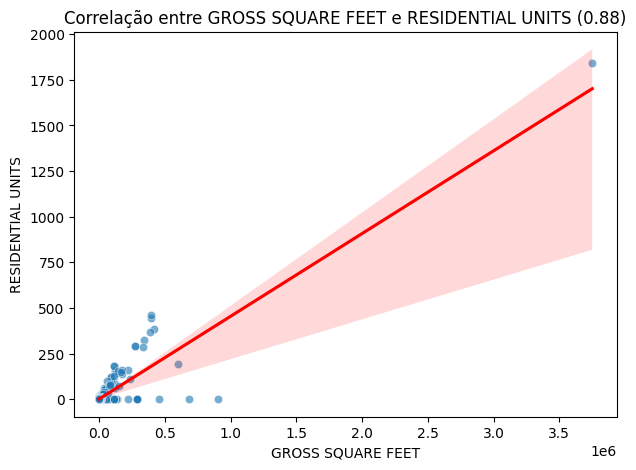

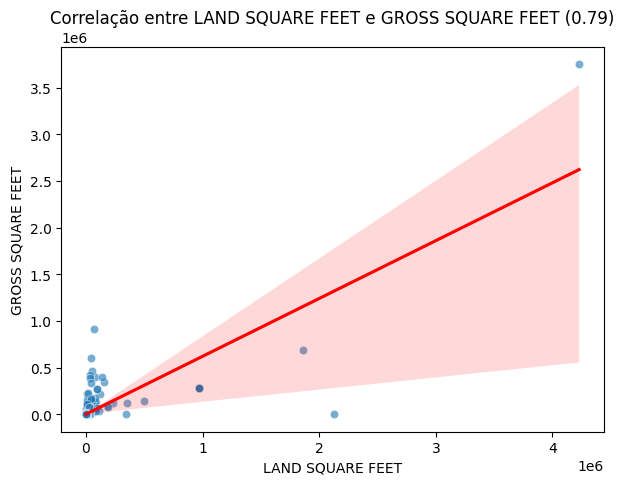

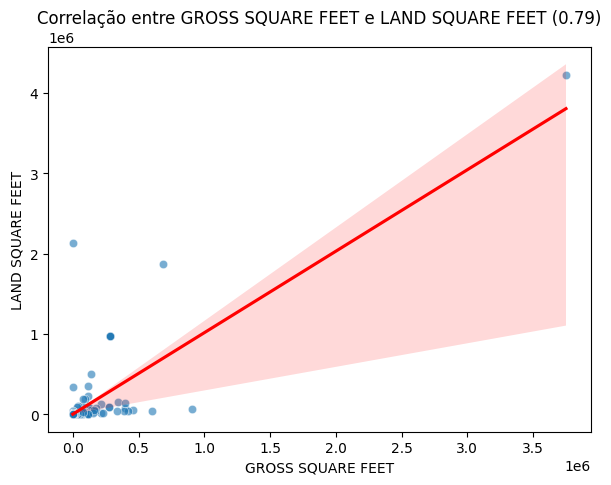

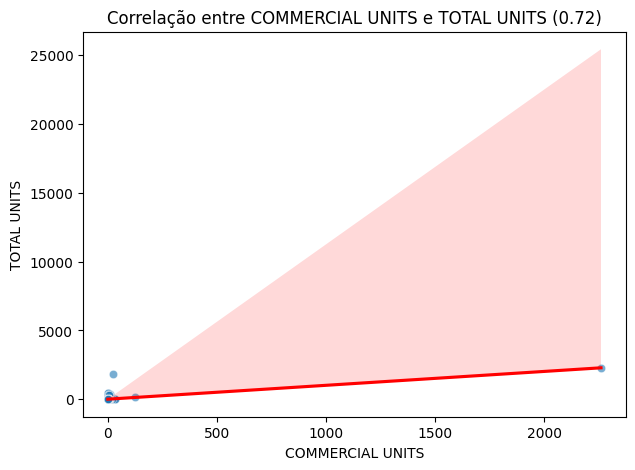

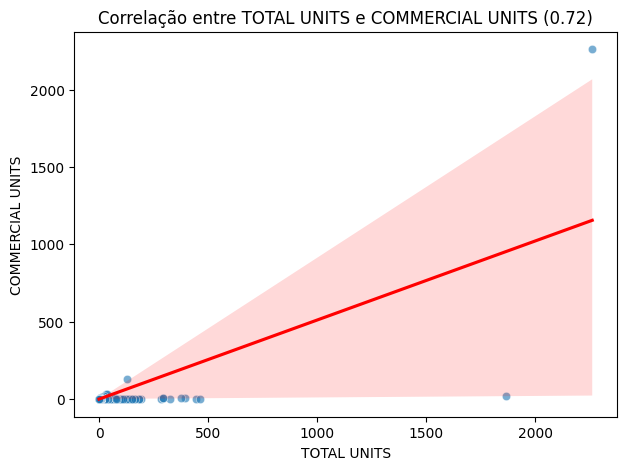

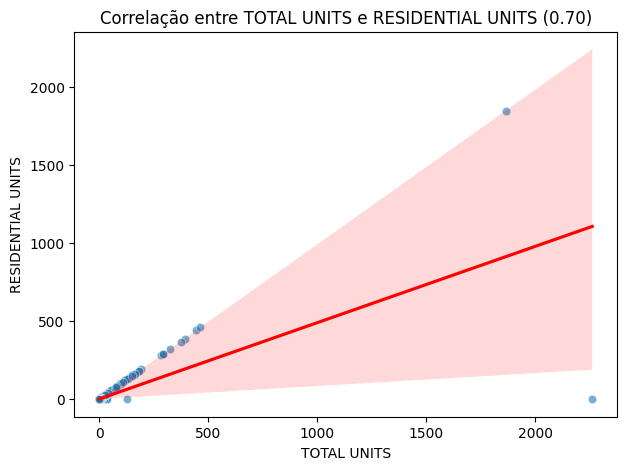

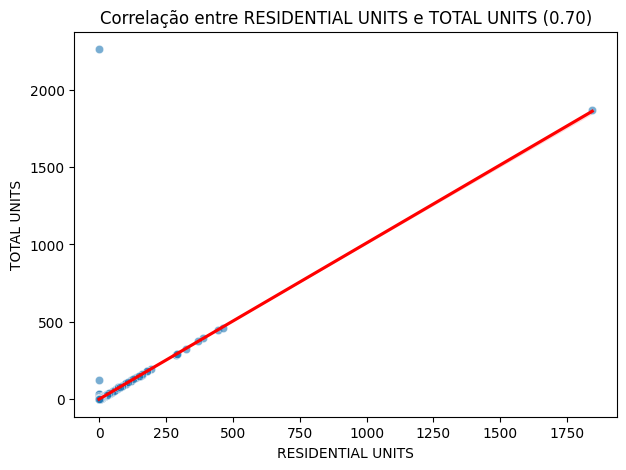

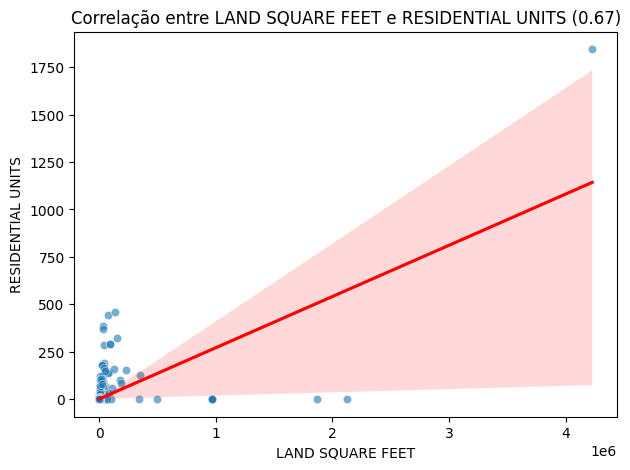

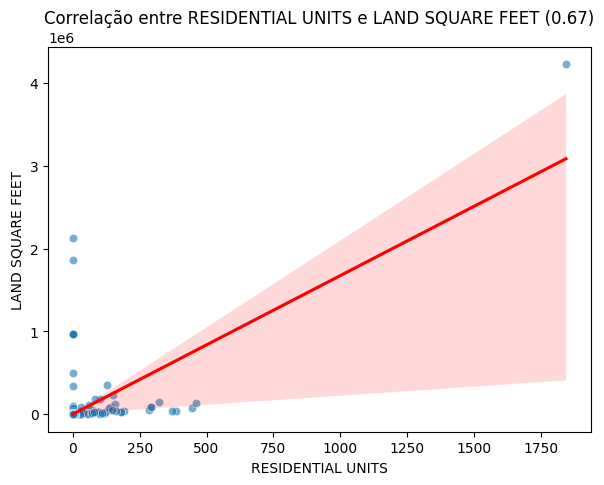

In [ ]:
pares_top = corr_fortes.head(10).index

for x, y in pares_top:

    plt.figure(figsize=(7,5))
    sns.scatterplot(x=asimov[x], y=asimov[y], alpha=0.6)
    sns.regplot(x=asimov[x], y=asimov[y], scatter=False, color='red')  # linha de tendencia
    plt.title(f'Correlação entre {x} e {y} ({corr.loc[x, y]:.2f})')
    plt.xlabel(x)
    plt.ylabel(y)
    plt.show()

In [ ]:
outliers_sale_price = detect_outliers_iqr(asimov, 'SALE PRICE')
print(f"Número de outliers em 'SALE PRICE': {len(outliers_sale_price)}")
print("Alguns outliers em 'SALE PRICE':")
print(outliers_sale_price[['SALE PRICE']].head())

Número de outliers em 'SALE PRICE': 328
Alguns outliers em 'SALE PRICE':
       SALE PRICE
7581    1425000.0
5703    1425000.0
6033    1400000.0
11711   1400000.0
12933   1450000.0


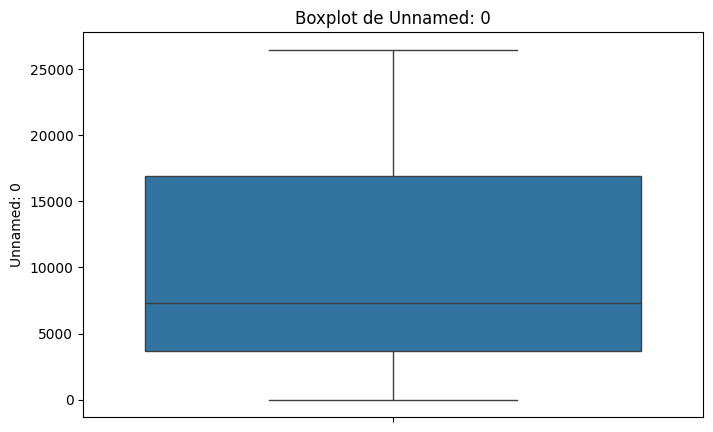

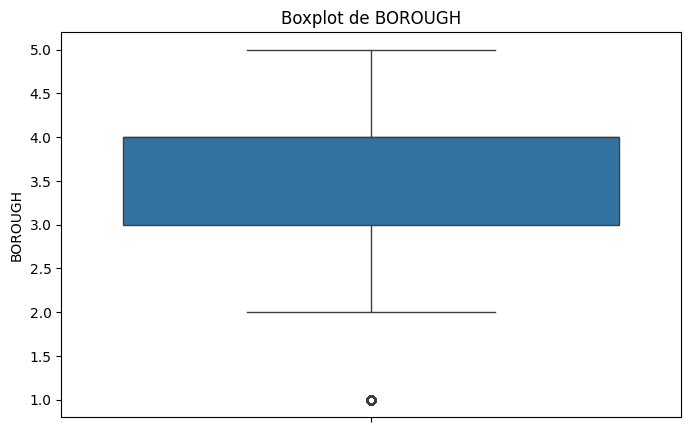

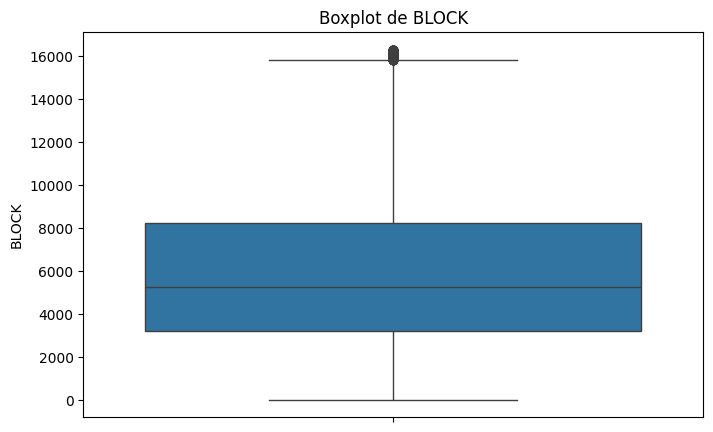

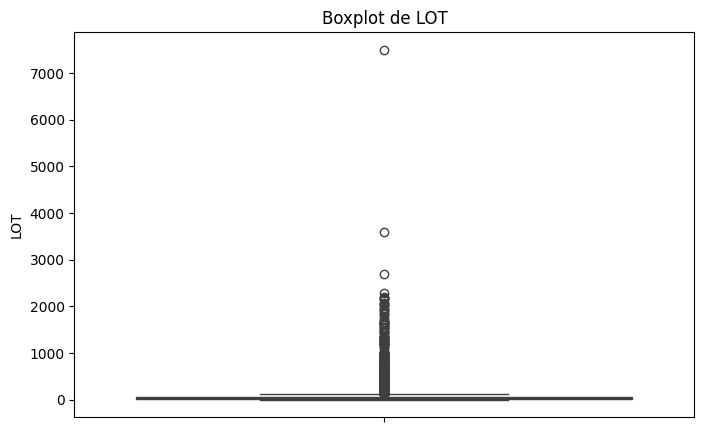

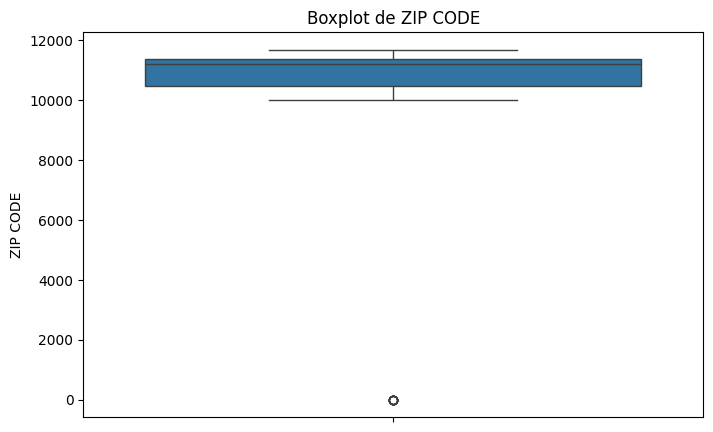

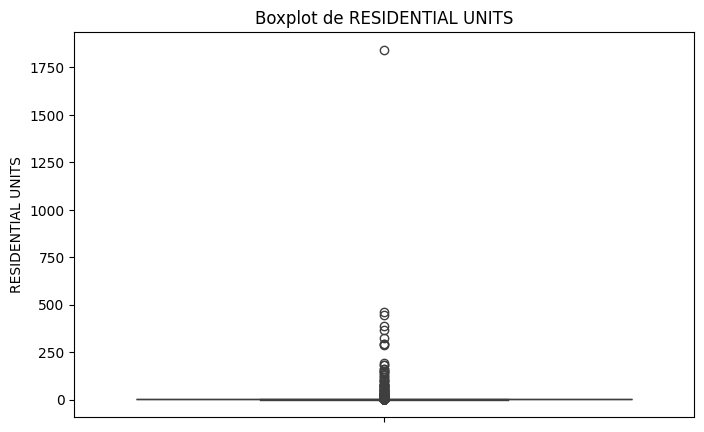

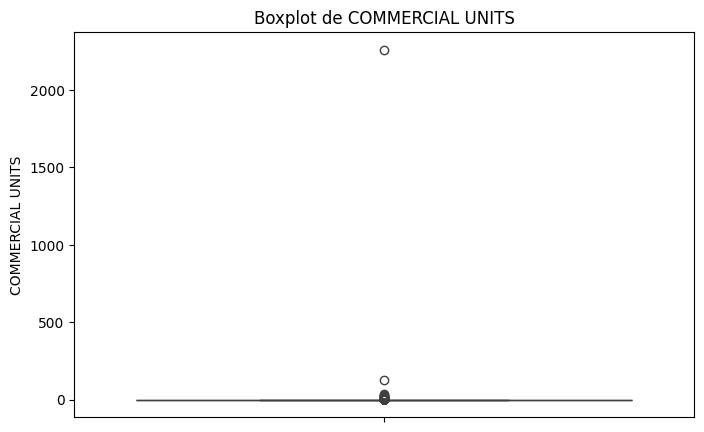

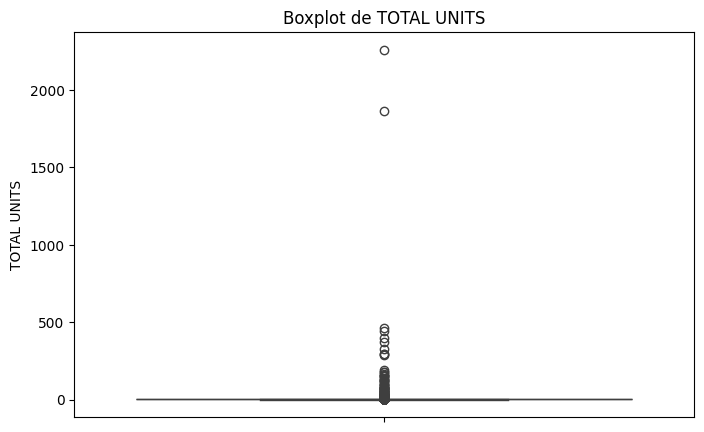

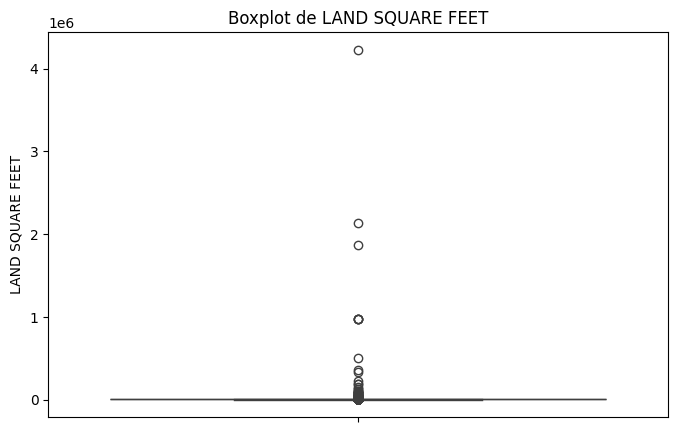

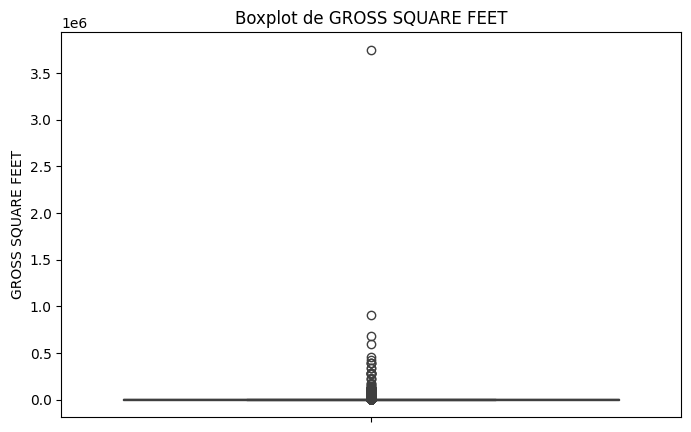

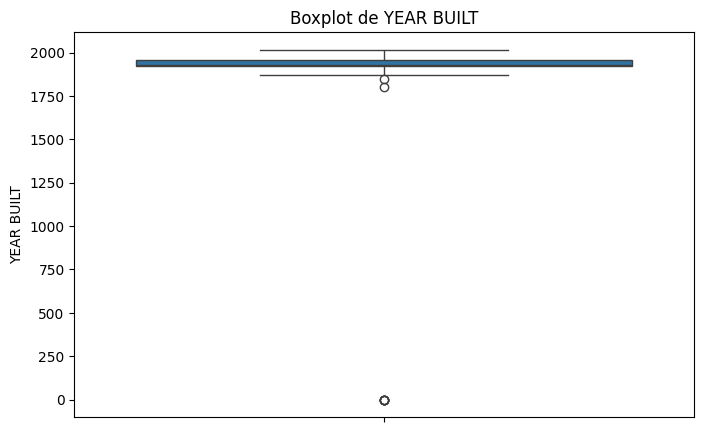

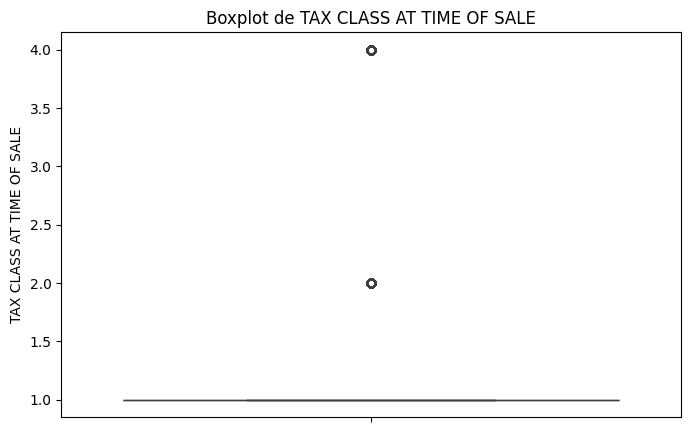

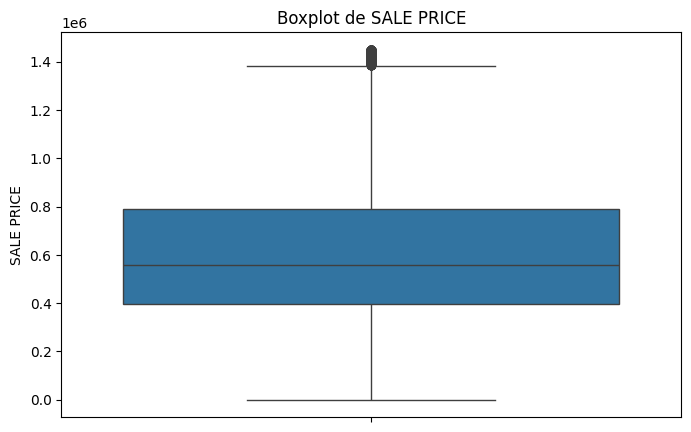

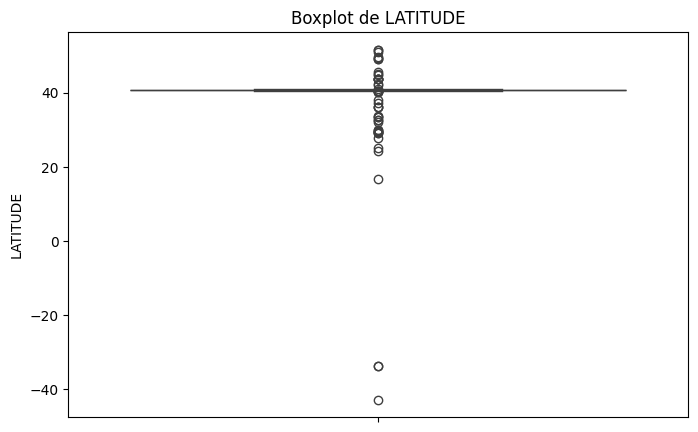

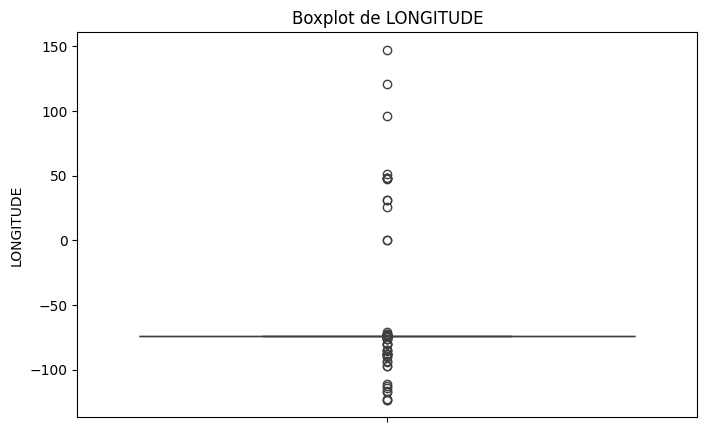

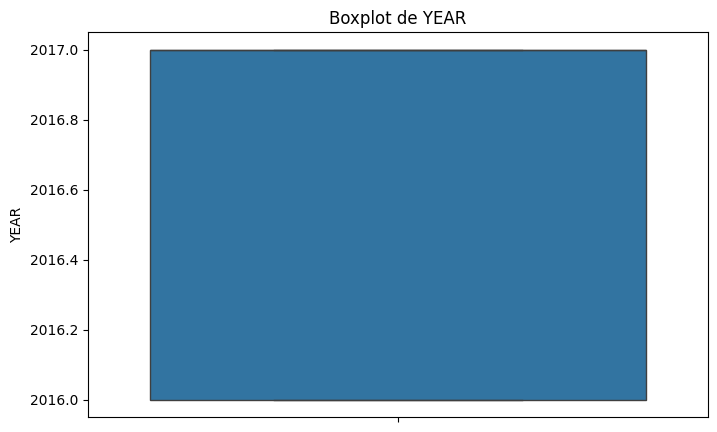

In [ ]:
for col in asimov.select_dtypes(include=np.number).columns:
    plt.figure(figsize=(8, 5))
    sns.boxplot(y=asimov[col])
    plt.title(f'Boxplot de {col}')
    plt.ylabel(col)
    plt.show()


/tmp/ipython-input-3113619151.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  asimov['YEAR_MONTH'] = asimov['SALE DATE'].dt.to_period('M')


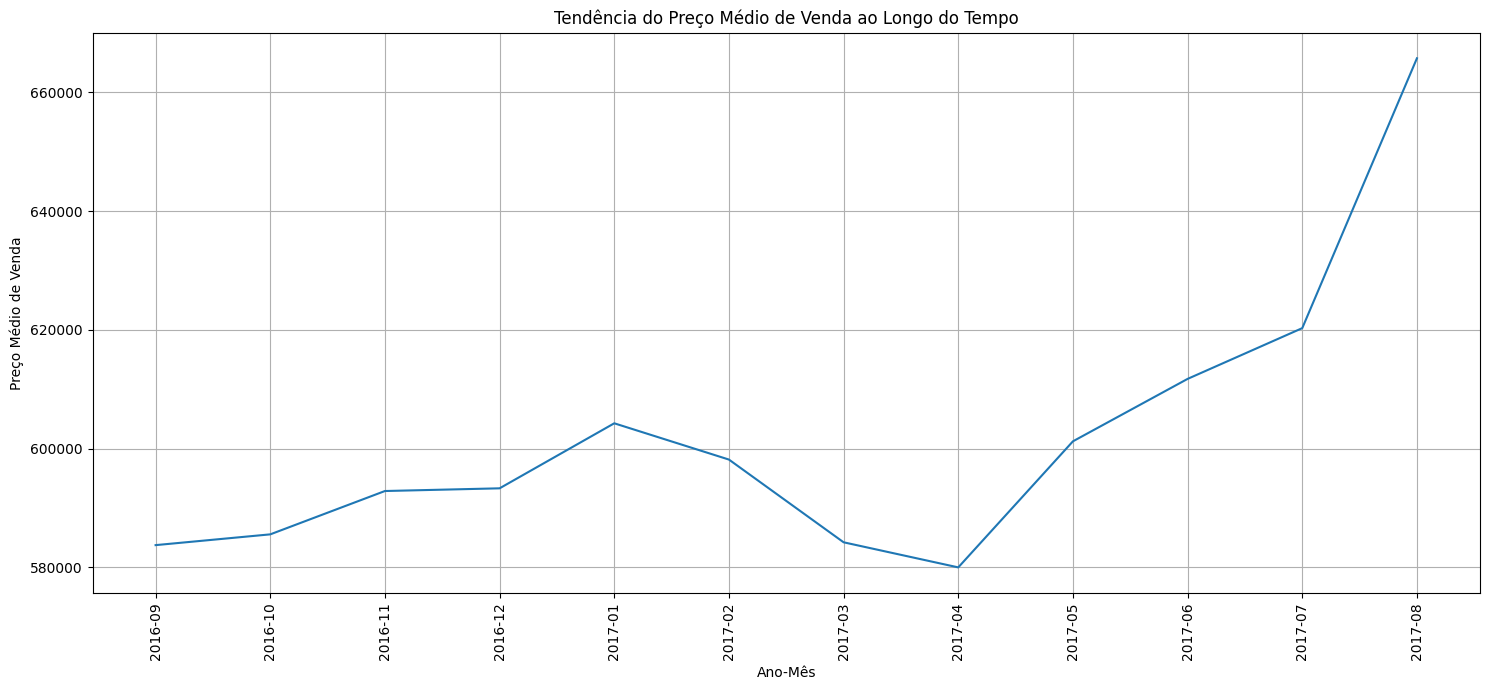

In [ ]:
# Tendência de preços ao longo do tempo
asimov['YEAR_MONTH'] = asimov['SALE DATE'].dt.to_period('M')
avg_price_month = asimov.groupby('YEAR_MONTH')['SALE PRICE'].mean().reset_index()
avg_price_month['YEAR_MONTH'] = avg_price_month['YEAR_MONTH'].astype(str)

plt.figure(figsize=(15, 7))
sns.lineplot(x='YEAR_MONTH', y='SALE PRICE', data=avg_price_month)
plt.title('Tendência do Preço Médio de Venda ao Longo do Tempo')
plt.xlabel('Ano-Mês')
plt.ylabel('Preço Médio de Venda')
plt.xticks(rotation=90)
plt.grid(True)
plt.tight_layout()
plt.show()

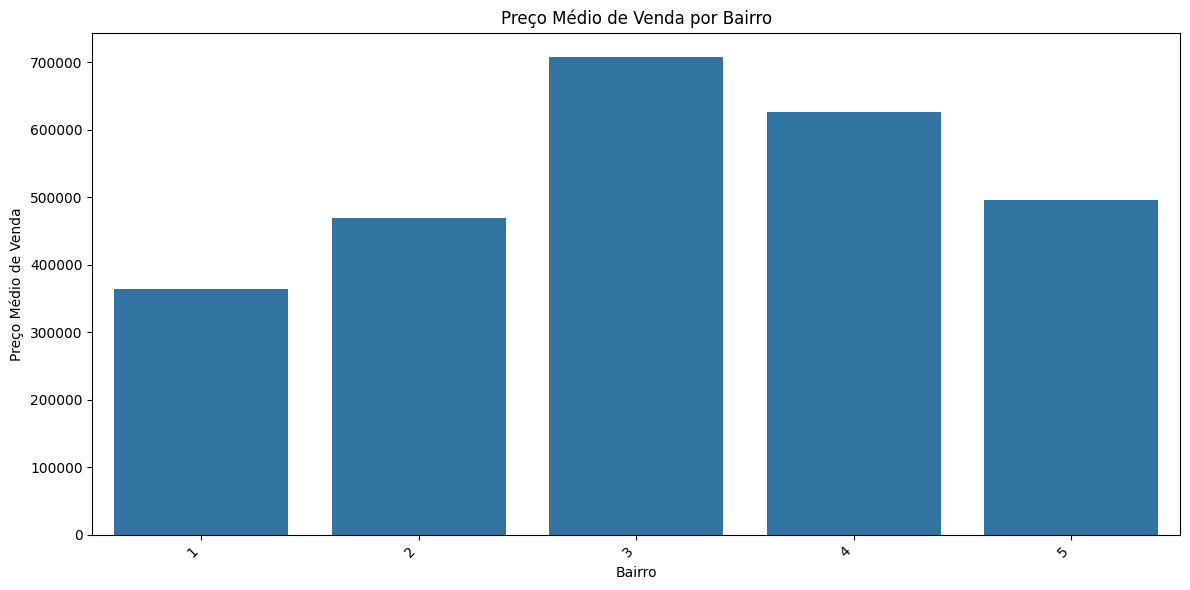

   BOROUGH     SALE PRICE
0        3  707867.543300
1        4  625651.037311
2        5  496136.494907
3        2  469380.004955
4        1  364120.010471


In [ ]:

avg_price_borough = asimov.groupby('BOROUGH')['SALE PRICE'].mean().sort_values(ascending=False).reset_index()
plt.figure(figsize=(12, 6))
sns.barplot(x='BOROUGH', y='SALE PRICE', data=avg_price_borough)
plt.title('Preço Médio de Venda por Bairro')
plt.xlabel('Bairro')
plt.ylabel('Preço Médio de Venda')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print(avg_price_borough)

In [ ]:

# Exemplo: Imóveis mais caros
print("Top 5 imóveis mais caros:")
print(asimov.nlargest(5, 'SALE PRICE'))

# Exemplo: Bairro com maior número de vendas
if 'BOROUGH' in asimov.columns:
    most_sales_borough = asimov['BOROUGH'].value_counts().idxmax()
    print(f"Bairro com o maior número de vendas: {most_sales_borough}")

# Exemplo: Tipo de imóvel mais comum
if 'BUILDING CLASS CATEGORY' in asimov.columns:
    most_common_building_type = asimov['BUILDING CLASS CATEGORY'].value_counts().idxmax()
    print(f"Tipo de imóvel mais comum: {most_common_building_type}")

print("Extração de informações concluída. Analise os resultados acima para insights específicos.")


Top 5 imóveis mais caros:
       Unnamed: 0  BOROUGH       NEIGHBORHOOD  \
12933       22491        3  WILLIAMSBURG-EAST   
16588        7711        4     FLUSHING-NORTH   
6250         4399        3       BOROUGH PARK   
10241       14420        3            GOWANUS   
21213       21706        4          RIDGEWOOD   

                           BUILDING CLASS CATEGORY TAX CLASS AT PRESENT  \
12933  02 TWO FAMILY DWELLINGS                                        1   
16588  02 TWO FAMILY DWELLINGS                                        1   
6250   07 RENTALS - WALKUP APARTMENTS                                2A   
10241  03 THREE FAMILY DWELLINGS                                      1   
21213  38 ASYLUMS AND HOMES                                           4   

       BLOCK  LOT EASE-MENT BUILDING CLASS AT PRESENT  \
12933   2754   23                                  S2   
16588   6357   16                                  B1   
6250    5297   70                                  C2   


### analisando dados categóricos

In [ ]:
asimov.select_dtypes('object')

,NEIGHBORHOOD,BUILDING CLASS CATEGORY,TAX CLASS AT PRESENT,EASE-MENT,BUILDING CLASS AT PRESENT,ADDRESS,APARTMENT NUMBER,BUILDING CLASS AT TIME OF SALE
22277,SOUTH JAMAICA,02 TWO FAMILY DWELLINGS,1,,B3,108-21 171ST PLACE,,B3
9404,FLATBUSH-EAST,01 ONE FAMILY DWELLINGS,1,,A2,4110 HUBBARD PLACE,,A2
19054,LITTLE NECK,01 ONE FAMILY DWELLINGS,1,,A2,262-03 60TH AVENUE,,A2
6958,CANARSIE,01 ONE FAMILY DWELLINGS,1,,A2,1165 EAST 88TH STREET,,A2
13759,BAYSIDE,01 ONE FAMILY DWELLINGS,1,,A2,210-24 33RD AVENUE,,A2
...,...,...,...,...,...,...,...,...
1080,BAYCHESTER,01 ONE FAMILY DWELLINGS,1,,A1,1611 GIVAN AVENUE,,A1
14559,CAMBRIA HEIGHTS,02 TWO FAMILY DWELLINGS,1,,B1,117-14 231ST STREET,,B1
14505,CAMBRIA HEIGHTS,01 ONE FAMILY DWELLINGS,1,,A2,118-10 230TH STREET,,A2
11741,OCEAN PARKWAY-NORTH,07 RENTALS - WALKUP APARTMENTS,2A,,C3,787 EAST 10 STREET,,C3


In [ ]:
# Estatísticas descritivas para colunas categóricas
print("Estatísticas descritivas para colunas categóricas:")
print(asimov.describe(include='object'))

Estatísticas descritivas para colunas categóricas:
          NEIGHBORHOOD                      BUILDING CLASS CATEGORY  \
count            25562                                        25562   
unique             234                                           26   
top     FLUSHING-NORTH  01 ONE FAMILY DWELLINGS                       
freq               705                                        12406   

       TAX CLASS AT PRESENT EASE-MENT BUILDING CLASS AT PRESENT  \
count                 25562     25562                     25562   
unique                    6         1                        95   
top                       1                                  A1   
freq                  23841     25562                      4660   

                     ADDRESS APARTMENT NUMBER BUILDING CLASS AT TIME OF SALE  
count                  25562            25562                          25562  
unique                 24692               24                             97  
top     102 WEST 57T

In [ ]:
count_vendas = asimov['SALE DATE'].astype('string').value_counts()

In [ ]:
asimov['SALE DATE'] = pd.to_datetime(asimov['SALE DATE'])
vendas_por_mes = asimov.groupby(pd.Grouper(key='SALE DATE', freq='M')).size()


/tmp/ipython-input-1838551953.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  asimov['SALE DATE'] = pd.to_datetime(asimov['SALE DATE'])
/tmp/ipython-input-1838551953.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  vendas_por_mes = asimov.groupby(pd.Grouper(key='SALE DATE', freq='M')).size()


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Converter para datetime
asimov['SALE DATE'] = pd.to_datetime(asimov['SALE DATE'])
asimov = asimov.sort_values(by='SALE DATE', ascending=True)
asimov['YEAR_MONTH'] = asimov['SALE DATE'].dt.to_period('M')

/tmp/ipython-input-2102044261.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  asimov['SALE DATE'] = pd.to_datetime(asimov['SALE DATE'])


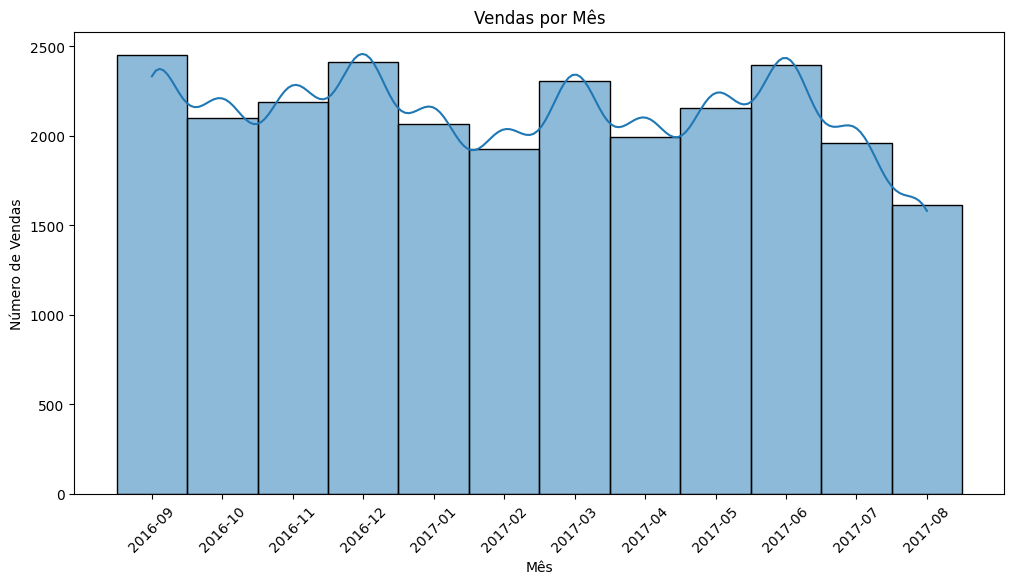

In [ ]:
plt.figure(figsize=(12,6))
sns.histplot(asimov['YEAR_MONTH'].astype(str), discrete=True, binwidth=1.0, kde=True)
plt.xlabel('Mês')
plt.ylabel('Número de Vendas')
plt.title('Vendas por Mês')
plt.xticks(rotation=45)
plt.show()


In [ ]:
import numpy as np
import pandas as pd

colunas_com_outliers = [
    'BLOCK',
    'LOT',
    'ZIP CODE',
    'RESIDENTIAL UNITS',
    'TOTAL UNITS',
    'LAND SQUARE FEET',
    'GROSS SQUARE FEET',
    'YEAR BUILT',
    'SALE PRICE'
]

df_limpo = asimov.copy()

print("\n--- Iniciando a remoção de outliers ---")

for coluna in colunas_com_outliers:
    df_limpo[coluna] = pd.to_numeric(df_limpo[coluna], errors='coerce')
    if not np.issubdtype(df_limpo[coluna].dtype, np.number):
        print(f"Coluna '{coluna}' ignorada (não numérica)")
        continue

    tamanho_antes = len(df_limpo)
    df_limpo = remove_outilier(coluna, df_limpo)
    tamanho_depois = len(df_limpo)
    print(f"Coluna '{coluna}': Removidos {tamanho_antes - tamanho_depois} outliers. Novo tamanho: {tamanho_depois}")

print("\n--- DataFrame Limpo (Primeiras 5 linhas) ---")
print(df_limpo.head())
print(f"\nTamanho final do DataFrame após a limpeza: {len(df_limpo)}")



--- Iniciando a remoção de outliers ---
Coluna 'BLOCK': Removidos 291 outliers. Novo tamanho: 25271
Coluna 'LOT': Removidos 2181 outliers. Novo tamanho: 23090
Coluna 'ZIP CODE': Removidos 5 outliers. Novo tamanho: 23085
Coluna 'RESIDENTIAL UNITS': Removidos 963 outliers. Novo tamanho: 22122
Coluna 'TOTAL UNITS': Removidos 140 outliers. Novo tamanho: 21982
Coluna 'LAND SQUARE FEET': Removidos 789 outliers. Novo tamanho: 21193
Coluna 'GROSS SQUARE FEET': Removidos 521 outliers. Novo tamanho: 20672
Coluna 'YEAR BUILT': Removidos 411 outliers. Novo tamanho: 20261
Coluna 'SALE PRICE': Removidos 333 outliers. Novo tamanho: 19928

--- DataFrame Limpo (Primeiras 5 linhas) ---
       Unnamed: 0  BOROUGH   NEIGHBORHOOD  \
22277       23250        4  SOUTH JAMAICA   
25424        1778        5    ELTINGVILLE   
20482       19857        4      REGO PARK   
27583        5592        5  PORT RICHMOND   
21138       21509        4      RIDGEWOOD   

                           BUILDING CLASS CATEGORY 

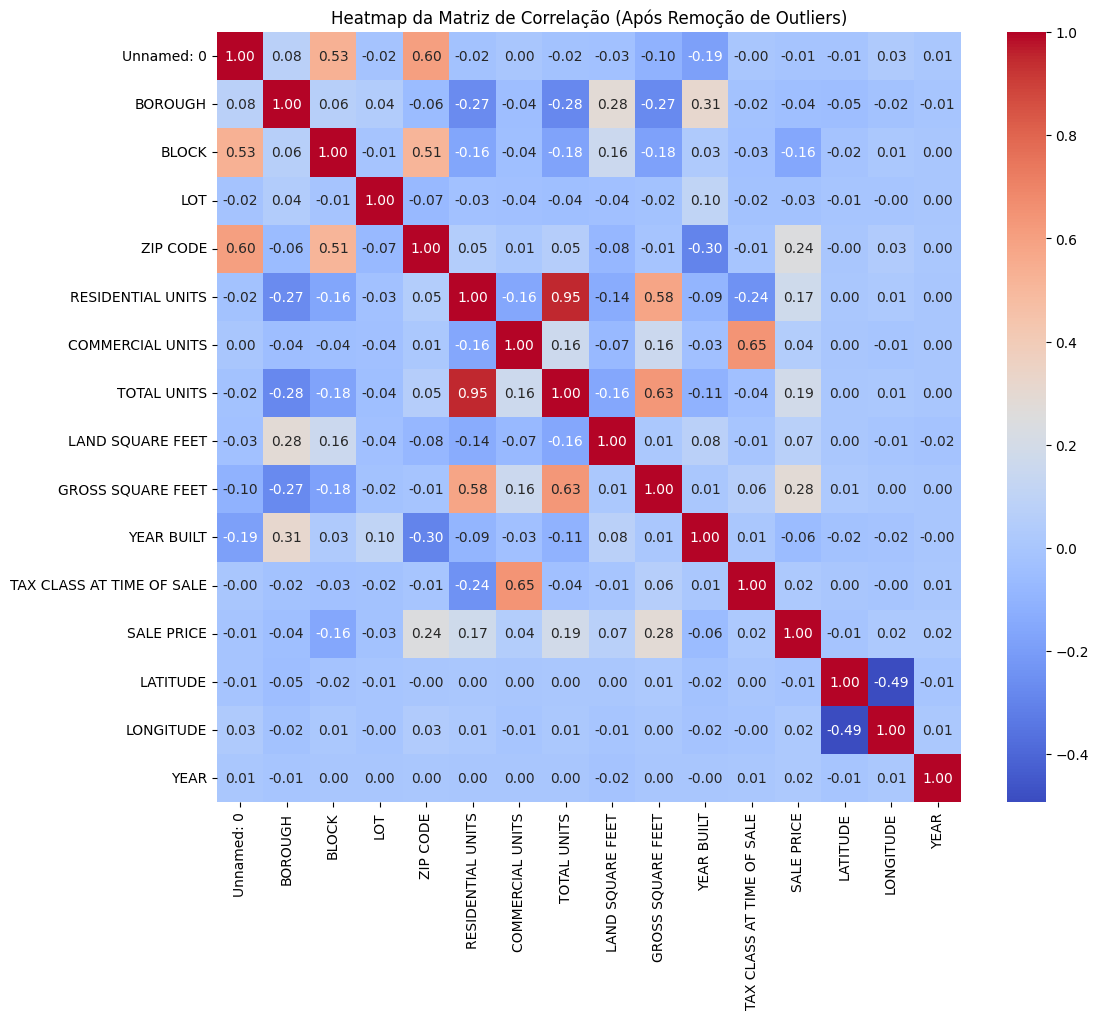

In [ ]:
correlation_matrix_limpo = df_limpo.select_dtypes(include=np.number).corr()

# Matriz de correlação com um heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix_limpo, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap da Matriz de Correlação (Após Remoção de Outliers)')
plt.show()

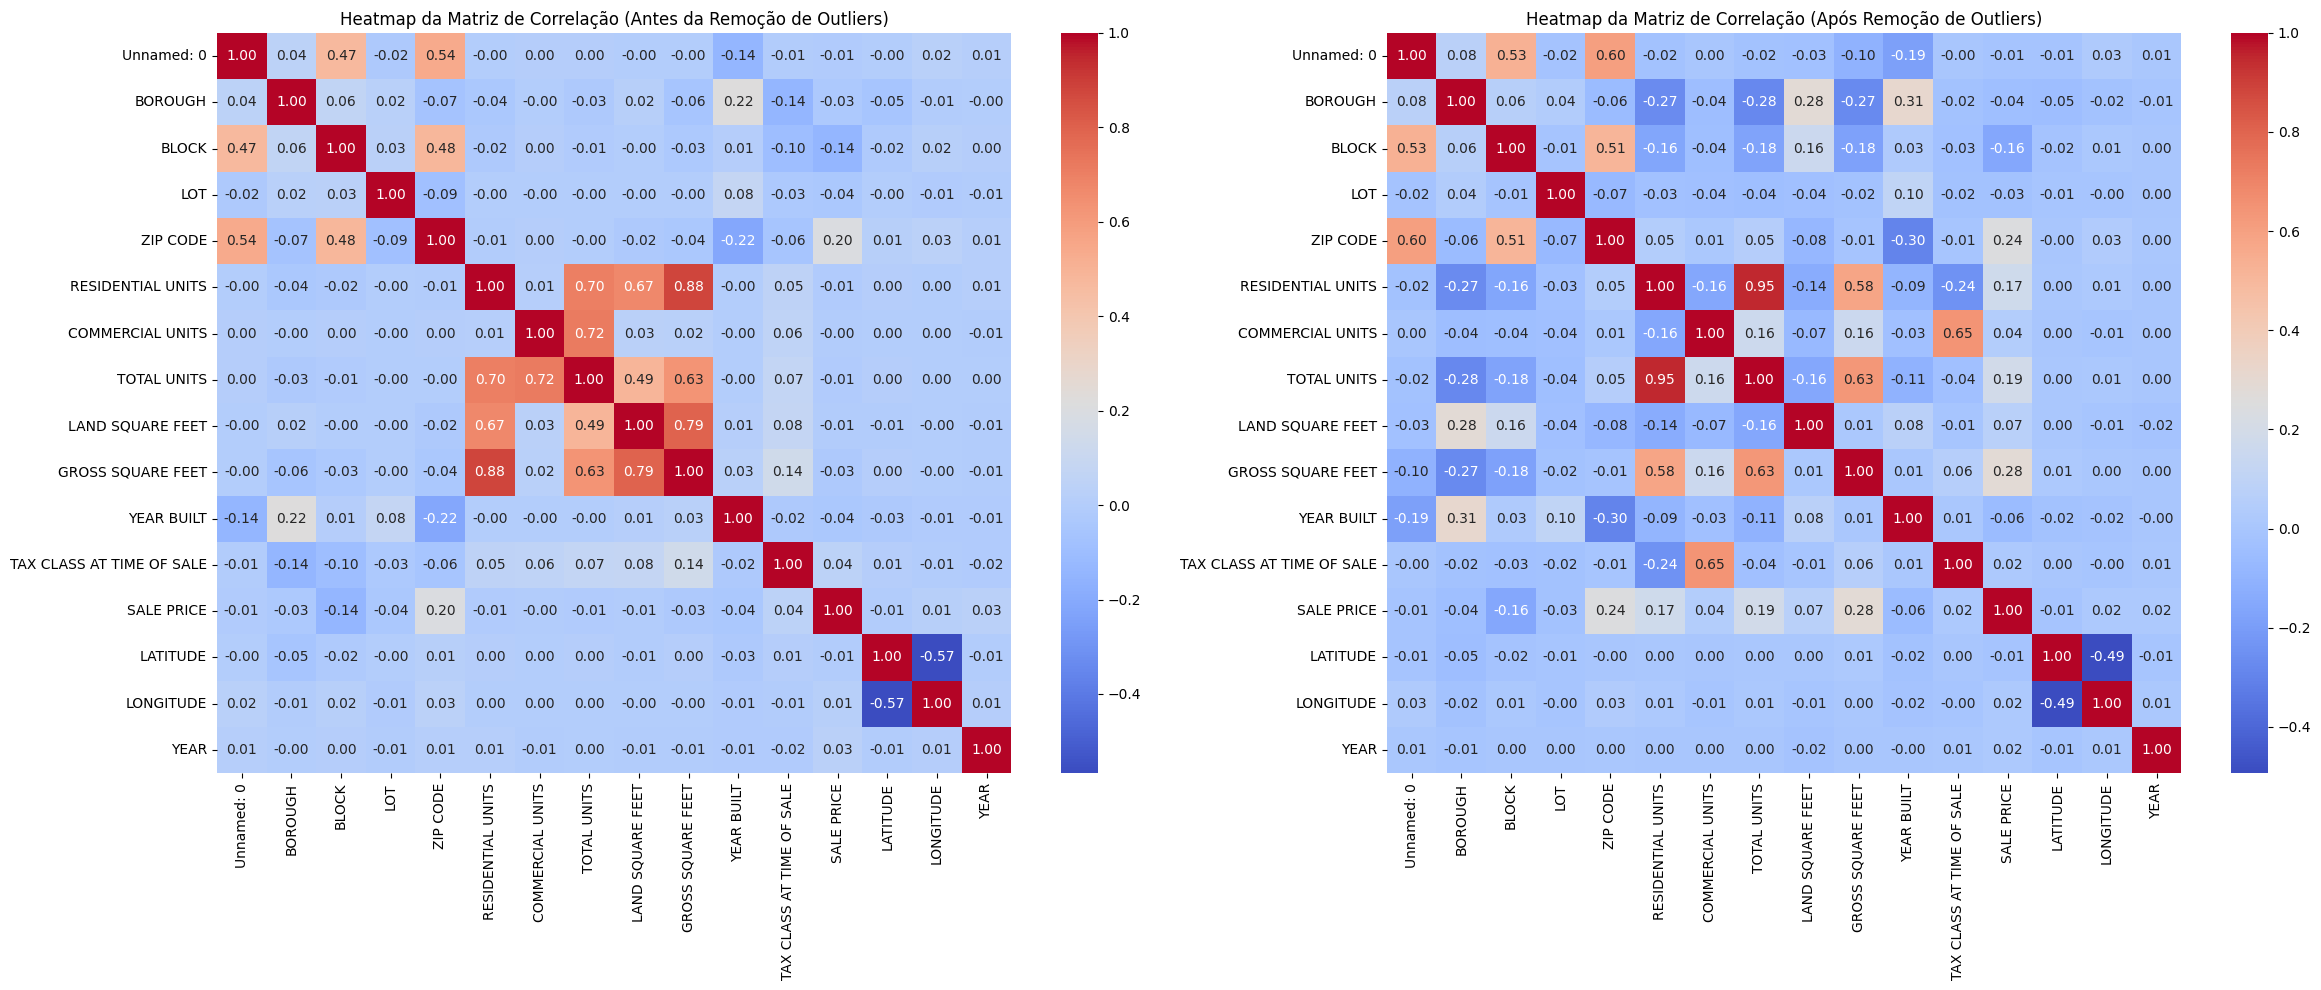

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(24, 10))

# Heatmap antes da remoção de outliers
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[0])
axes[0].set_title('Heatmap da Matriz de Correlação (Antes da Remoção de Outliers)')

# Heatmap após a remoção de outliers
sns.heatmap(correlation_matrix_limpo, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[1])
axes[1].set_title('Heatmap da Matriz de Correlação (Após Remoção de Outliers)')

plt.tight_layout()
plt.show()

# Regressão

## Treinamento de regressores

### Preparação

In [ ]:
# asimov_ini = pd.read_csv('cleaned_data_inicial.csv') # Removing this line as it's not needed
X = asimov.loc[filtro_outlier.index, 'GROSS SQUARE FEET'] # Use the asimov DataFrame after outlier removal
y = filtro_outlier['SALE PRICE'] # Use the asimov DataFrame after outlier removal

In [ ]:
from sklearn.model_selection import train_test_split
SQUARE_FEET_range = pd.DataFrame({
    'GROSS SQUARE FEET':list(range(1,10))
})
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1, random_state=42)

### Fit Linear

Text(0, 0.5, 'Preço de Venda')

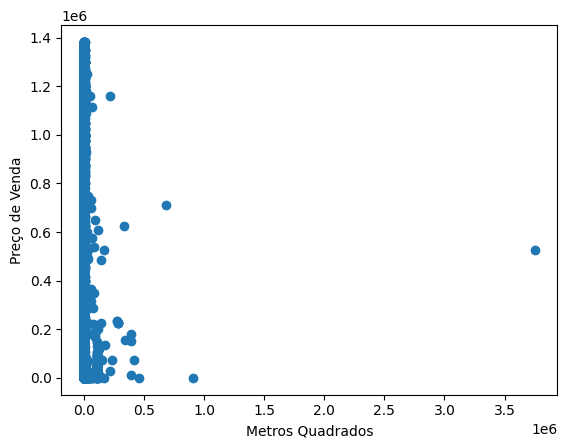

In [ ]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
# Reshape X_train and X_test to be 2D arrays
lin_reg.fit(X_train.values.reshape(-1, 1), y_train)
y_pred = lin_reg.predict(X_test.values.reshape(-1, 1))

plt.scatter(X, y)
# Reshape BOROUGH_range to be 2D for prediction
plt.plot(SQUARE_FEET_range, lin_reg.predict(SQUARE_FEET_range.values.reshape(-1, 1)), color='red')
plt.xlabel('Metros Quadrados')
plt.ylabel('Preço de Venda')

### Arvore de decisão

Text(0, 0.5, 'Salário')

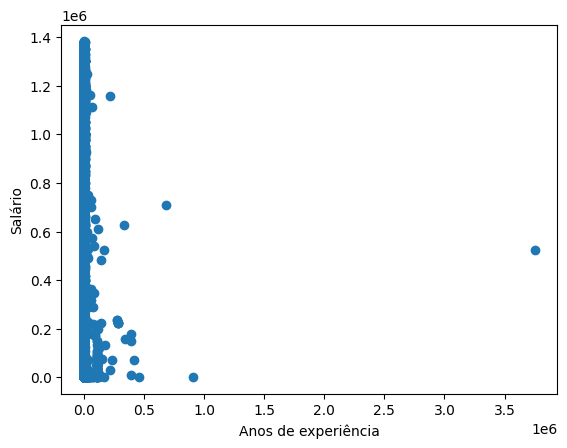

In [ ]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = DecisionTreeRegressor(random_state=42, max_depth=4)
tree_reg.fit(X_train.values.reshape(-1, 1), y_train)
y_pred = tree_reg.predict(X_test.values.reshape(-1, 1))

plt.scatter(X,y)
plt.plot(SQUARE_FEET_range.values.reshape(-1, 1), tree_reg.predict(SQUARE_FEET_range.values.reshape(-1, 1)), color='orange')
plt.xlabel('Anos de experiência')
plt.ylabel('Salário')

## Linear Regression

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error

# Base limpa
df = df_limpo.copy()

# Remover colunas irrelevantes
columns_to_drop = [
    'ADDRESS', 'EASE-MENT', 'SALE DATE', 'ZIP CODE',
    'BUILDING CLASS AT TIME OF SALE', 'BUILDING CLASS AT PRESENT',
    'LATITUDE', 'LONGITUDE', 'TAX CLASS AT PRESENT',
    'TAX CLASS AT TIME OF SALE', 'NEIGHBORHOOD', 'APARTMENT NUMBER'
]
df = df.drop(columns=columns_to_drop, errors='ignore')

# One-hot encoding
df_encoded = pd.get_dummies(df, drop_first=True)

# Separar variáveis independentes e dependente
X = df_encoded.drop(columns=['SALE PRICE'])
y = df_encoded['SALE PRICE']

# Escalonar variáveis
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Separar treino e teste
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Modelo com regularização
model = Ridge(alpha=1.0)
model.fit(X_train, y_train)

# Predições
y_pred = model.predict(X_test)

# Avaliação
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\n=== Avaliação do Modelo ===")
print(f"R²: {r2:.3f}")
print(f"RMSE: {rmse:.2f}")

# Coeficientes
coef_df = pd.DataFrame({
    'Variável': X.columns,
    'Coeficiente': model.coef_
}).sort_values(by='Coeficiente', ascending=False)

print("\nCoeficientes do Modelo:")
print(coef_df.head(15))


TypeError: Cannot cast PeriodArray to dtype float64

## Random Forest Regression

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Carregar dataset
df = pd.read_csv("cleaned_data.csv")

columns_to_drop = [
    'ADDRESS',
    'EASE-MENT',
    'SALE DATE',
    'ZIP CODE',
    'BUILDING CLASS AT TIME OF SALE',
    'BUILDING CLASS AT PRESENT',
    'LATITUDE',
    'LONGITUDE',
    'TAX CLASS AT PRESENT',
    'TAX CLASS AT TIME OF SALE',
    'NEIGHBORHOOD',
    'APARTMENT NUMBER'
]

df = df.drop(columns=columns_to_drop)

# Converter colunas categóricas para numéricas (one-hot encoding)
df_encoded = pd.get_dummies(df, drop_first=True)

# Separar variáveis independentes e dependente
X = df_encoded.drop(columns=['SALE PRICE'])
y = df_encoded['SALE PRICE']

# Separar treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Criar e treinar o modelo Random Forest
model = RandomForestRegressor(
    n_estimators=200,        # número de árvores
    max_depth=None,          # profundidade ilimitada
    min_samples_split=2,     # mínimo para dividir um nó
    min_samples_leaf=1,      # mínimo por folha
    random_state=42,
    n_jobs=-1                # usa todos os núcleos da CPU
)

model.fit(X_train, y_train)

# Fazer previsões
y_pred = model.predict(X_test)

# Avaliar o modelo
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\n=== Avaliação do Modelo Random Forest ===")
print(f"R²: {r2:.3f}")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

# Mostrar importância das variáveis
feature_importance = pd.DataFrame({
    'Variável': X.columns,
    'Importância': model.feature_importances_
}).sort_values(by='Importância', ascending=False)

print("\nImportância das Variáveis:")
print(feature_importance)
